# Lab 1 – EDA Text: IMDB Dataset of 50K Movie Reviews

**Môn:** Data Mining  
**Dataset:** [IMDB Dataset of 50K Movie Reviews – Kaggle](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)  

---
## Mục lục
- [0. Cài đặt & Load dữ liệu](#setup)
- [a) Phân phối độ dài văn bản & Mann–Whitney U test](#partA)
- [b) Word Cloud, Top-50 từ phổ biến & Type-Token Ratio](#partB)
- [c) Phân tích phân phối Zipf](#partC)

---
<a id='setup'></a>
## 0. Cài đặt thư viện & Load dữ liệu từ Google Drive

In [1]:
# Cài đặt thư viện cần thiết
!pip install wordcloud scipy matplotlib seaborn pandas numpy -q

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import re

CSV_PATH = '/content/drive/MyDrive/Data Mining/IMDB Dataset.csv'

df = pd.read_csv(CSV_PATH)
print('Shape:', df.shape)
print(df['sentiment'].value_counts())
df.head(3)

Shape: (50000, 2)
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


In [4]:
# Làm sạch HTML tags cơ bản
def clean_html(text):
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_review'] = df['review'].apply(clean_html)

# Tính độ dài
df['word_count'] = df['clean_review'].apply(lambda x: len(x.split()))
df['char_count'] = df['clean_review'].apply(len)

print('Thống kê word_count:')
print(df.groupby('sentiment')['word_count'].describe().round(2))

Thống kê word_count:
             count    mean     std   min    25%    50%    75%     max
sentiment                                                            
negative   25000.0  227.11  163.18   4.0  127.0  172.0  275.0  1491.0
positive   25000.0  230.62  175.75  10.0  124.0  171.0  280.0  2459.0


---
<a id='partA'></a>
## a) Phân phối độ dài văn bản & Kiểm định Mann–Whitney U Test

### Lý thuyết

#### 1. Độ dài văn bản
Hai đặc trưng cơ bản về độ dài của một văn bản:
- **Số từ (word count):** $L_w = |\{w_1, w_2, \ldots, w_n\}|$ – tổng số token sau khi tách từ (whitespace tokenization).
- **Số ký tự (char count):** $L_c = |s|$ – độ dài chuỗi ký tự của văn bản (bao gồm dấu câu và khoảng trắng).

Phân phối độ dài thường có dạng **lệch phải (right-skewed)** – phần lớn văn bản có độ dài trung bình, nhưng có một số văn bản rất dài.

#### 2. Kiểm định Mann–Whitney U Test
Mann–Whitney U test (hay Wilcoxon rank-sum test) là kiểm định **phi tham số** dùng để so sánh hai nhóm độc lập, **không** yêu cầu giả định phân phối chuẩn.

**Giả thuyết:**
$$H_0: P(X_1 > X_2) = 0.5 \quad \text{(hai phân phối giống nhau)}$$
$$H_1: P(X_1 > X_2) \neq 0.5 \quad \text{(hai phân phối khác nhau)}$$

**Thống kê U:**
$$U_1 = n_1 n_2 + \frac{n_1(n_1+1)}{2} - R_1$$

Trong đó $R_1$ là tổng hạng (rank) của nhóm 1, $n_1, n_2$ là kích thước hai mẫu.

**Quyết định:** Bác bỏ $H_0$ nếu $p\text{-value} < \alpha = 0.05$.

> **Tại sao dùng Mann–Whitney thay vì t-test?**  
> Phân phối độ dài văn bản thường lệch phải và có outliers → vi phạm giả định chuẩn của t-test. Mann–Whitney U test mạnh hơn trong trường hợp này vì làm việc trên hạng (rank) thay vì giá trị thực.

In [5]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import mannwhitneyu

# Tách theo nhãn
pos = df[df['sentiment'] == 'positive']
neg = df[df['sentiment'] == 'negative']

# ---- Mann–Whitney U Test ----
u_word, p_word = mannwhitneyu(pos['word_count'], neg['word_count'], alternative='two-sided')
u_char, p_char = mannwhitneyu(pos['char_count'], neg['char_count'], alternative='two-sided')

print('=== Mann–Whitney U Test ===')
print(f'Word Count  → U = {u_word:.0f}, p-value = {p_word:.4e}')
print(f'Char Count  → U = {u_char:.0f}, p-value = {p_char:.4e}')
print()
alpha = 0.05
for name, p in [('Word Count', p_word), ('Char Count', p_char)]:
    if p < alpha:
        print(f'[{name}] Bác bỏ H0: Có sự khác biệt có ý nghĩa thống kê (p < {alpha})')
    else:
        print(f'[{name}] Không bác bỏ H0: Không có sự khác biệt có ý nghĩa (p >= {alpha})')

=== Mann–Whitney U Test ===
Word Count  → U = 309193054, p-value = 4.0439e-02
Char Count  → U = 310755294, p-value = 2.7963e-01

[Word Count] Bác bỏ H0: Có sự khác biệt có ý nghĩa thống kê (p < 0.05)
[Char Count] Không bác bỏ H0: Không có sự khác biệt có ý nghĩa (p >= 0.05)


/tmp/ipykernel_1867/1305028834.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sentiment', y='word_count', palette=palette,
/tmp/ipykernel_1867/1305028834.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sentiment', y='char_count', palette=palette,


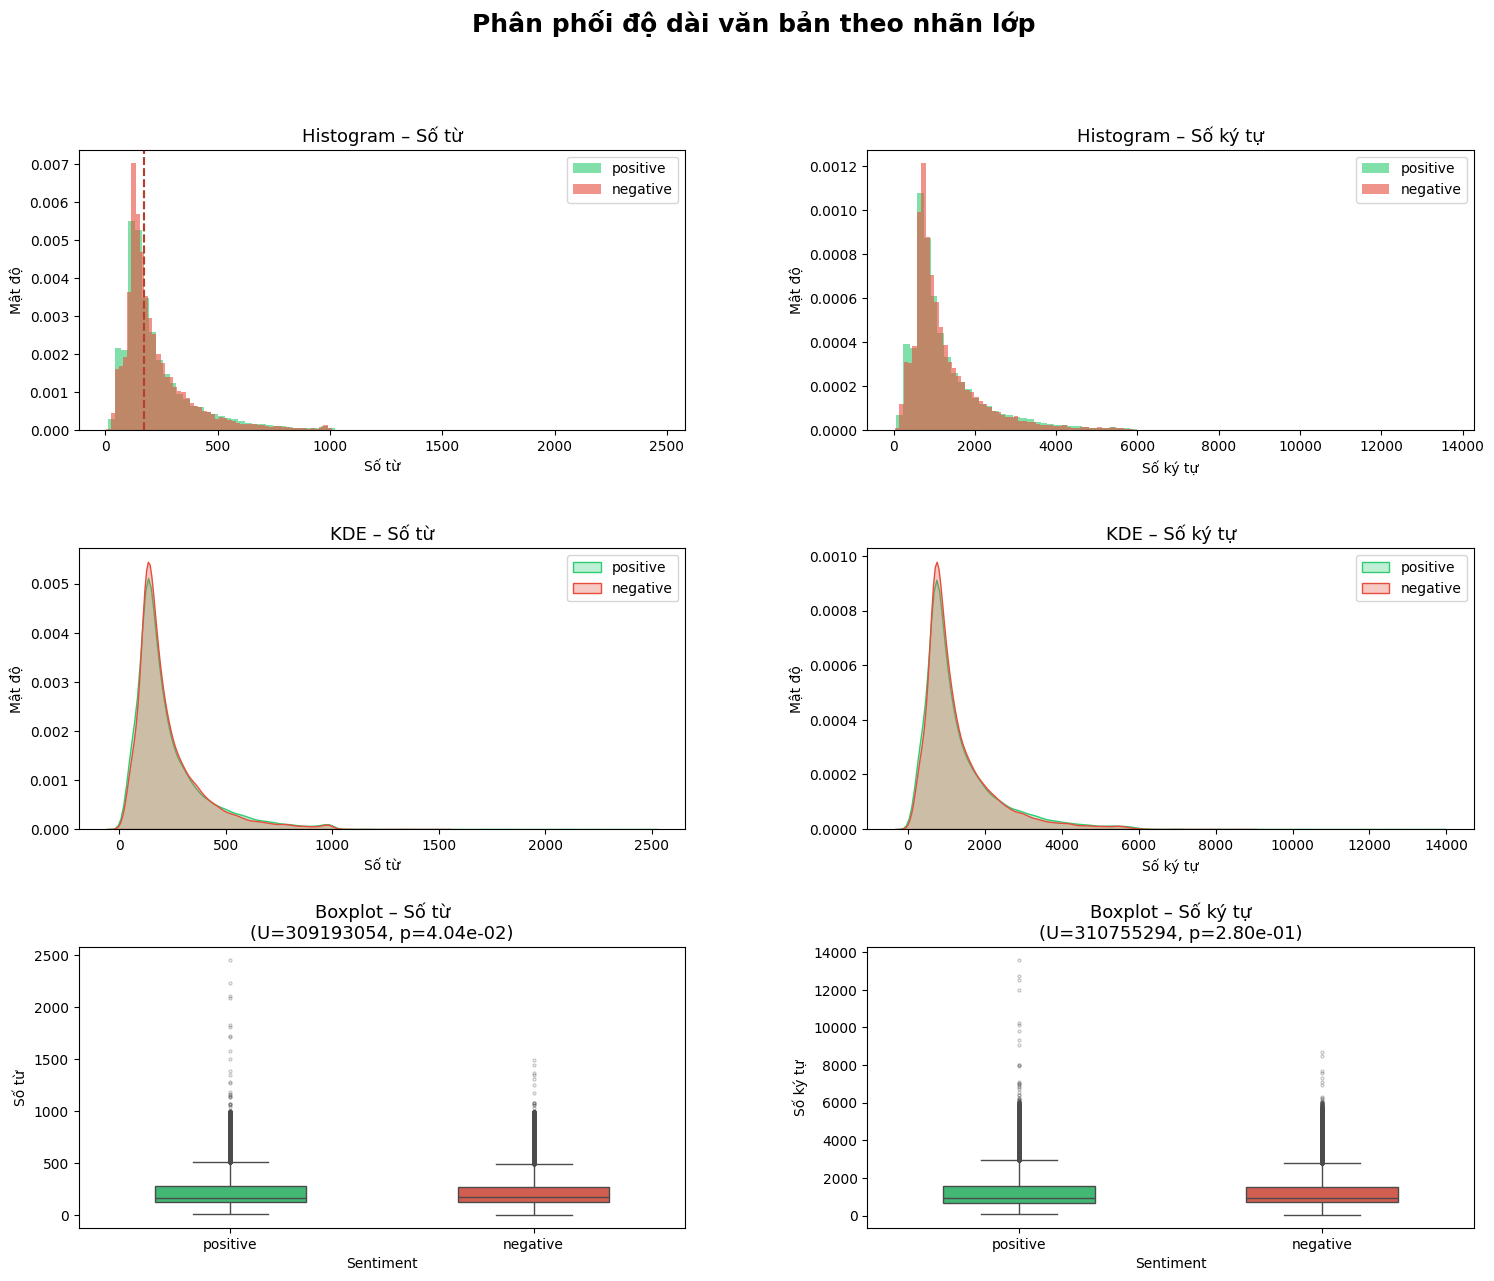

Đã lưu: /content/a_length_distribution.png


In [6]:
# ---- Vẽ biểu đồ ----
palette = {'positive': '#2ecc71', 'negative': '#e74c3c'}

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Phân phối độ dài văn bản theo nhãn lớp', fontsize=18, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(3, 2, hspace=0.42, wspace=0.3)

# 1. Histogram – word count
ax1 = fig.add_subplot(gs[0, 0])
for sent, color in palette.items():
    subset = df[df['sentiment'] == sent]['word_count']
    ax1.hist(subset, bins=80, alpha=0.6, color=color, label=sent, density=True)
ax1.set_title('Histogram – Số từ', fontsize=13)
ax1.set_xlabel('Số từ'); ax1.set_ylabel('Mật độ')
ax1.legend()
ax1.axvline(pos['word_count'].median(), color='#27ae60', ls='--', lw=1.5, label='median pos')
ax1.axvline(neg['word_count'].median(), color='#c0392b', ls='--', lw=1.5, label='median neg')

# 2. Histogram – char count
ax2 = fig.add_subplot(gs[0, 1])
for sent, color in palette.items():
    subset = df[df['sentiment'] == sent]['char_count']
    ax2.hist(subset, bins=80, alpha=0.6, color=color, label=sent, density=True)
ax2.set_title('Histogram – Số ký tự', fontsize=13)
ax2.set_xlabel('Số ký tự'); ax2.set_ylabel('Mật độ')
ax2.legend()

# 3. KDE – word count
ax3 = fig.add_subplot(gs[1, 0])
for sent, color in palette.items():
    sns.kdeplot(df[df['sentiment'] == sent]['word_count'], ax=ax3,
                color=color, fill=True, alpha=0.3, label=sent)
ax3.set_title('KDE – Số từ', fontsize=13)
ax3.set_xlabel('Số từ'); ax3.set_ylabel('Mật độ'); ax3.legend()

# 4. KDE – char count
ax4 = fig.add_subplot(gs[1, 1])
for sent, color in palette.items():
    sns.kdeplot(df[df['sentiment'] == sent]['char_count'], ax=ax4,
                color=color, fill=True, alpha=0.3, label=sent)
ax4.set_title('KDE – Số ký tự', fontsize=13)
ax4.set_xlabel('Số ký tự'); ax4.set_ylabel('Mật độ'); ax4.legend()

# 5. Boxplot – word count
ax5 = fig.add_subplot(gs[2, 0])
sns.boxplot(data=df, x='sentiment', y='word_count', palette=palette,
            order=['positive','negative'], ax=ax5, width=0.5,
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax5.set_title(f'Boxplot – Số từ\n(U={u_word:.0f}, p={p_word:.2e})', fontsize=13)
ax5.set_xlabel('Sentiment'); ax5.set_ylabel('Số từ')

# 6. Boxplot – char count
ax6 = fig.add_subplot(gs[2, 1])
sns.boxplot(data=df, x='sentiment', y='char_count', palette=palette,
            order=['positive','negative'], ax=ax6, width=0.5,
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax6.set_title(f'Boxplot – Số ký tự\n(U={u_char:.0f}, p={p_char:.2e})', fontsize=13)
ax6.set_xlabel('Sentiment'); ax6.set_ylabel('Số ký tự')

plt.savefig('/content/a_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Đã lưu: /content/a_length_distribution.png')

In [7]:
# Thống kê mô tả chi tiết
stats_df = df.groupby('sentiment')[['word_count','char_count']].agg(
    ['mean','median','std','min','max',
     lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]
).round(2)
stats_df.columns = ['_'.join(c).replace('<lambda_0>','Q1').replace('<lambda_1>','Q3')
                    for c in stats_df.columns]
print(stats_df.T)

sentiment          negative  positive
word_count_mean      227.11    230.62
word_count_median    172.00    171.00
word_count_std       163.18    175.75
word_count_min         4.00     10.00
word_count_max      1491.00   2459.00
word_count_Q1        127.00    124.00
word_count_Q3        275.00    280.00
char_count_mean     1270.87   1302.94
char_count_median    957.00    952.00
char_count_std       928.34   1014.36
char_count_min        32.00     65.00
char_count_max      8698.00  13593.00
char_count_Q1        696.75    683.00
char_count_Q3       1537.00   1585.00


### Phân tích kết quả – Phần a)

#### 1. Thống kê mô tả độ dài văn bản

| Đặc trưng | Negative | Positive |
|-----------|----------|----------|
| Mean (từ) | 227.11 | 230.62 |
| Median (từ) | 172.00 | 171.00 |
| Std (từ) | 163.18 | 175.75 |
| Min / Max (từ) | 4 / 1491 | 10 / 2459 |
| Q1 / Q3 (từ) | 127 / 275 | 124 / 280 |
| Mean (ký tự) | 1270.87 | 1302.94 |
| Median (ký tự) | 957.00 | 952.00 |

**Nhận xét:**
- **Phân phối lệch phải rõ rệt:** Mean >> Median ở cả hai lớp (word count: mean ≈ 228–231 từ, median ≈ 171–172 từ), cho thấy tồn tại một số review rất dài kéo mean lên cao. Điều này thể hiện rõ trên histogram và KDE — đỉnh phân phối nằm ở khoảng 100–200 từ, đuôi phải kéo dài đến 2500 từ.
- **Outliers nhiều:** Positive có max = 2459 từ / 13593 ký tự, Negative có max = 1491 từ / 8698 ký tự — khoảng cách IQR (Q3 − Q1 ≈ 148–156 từ) nhỏ hơn nhiều so với khoảng max, cho thấy các điểm outliers rất xa so với phần lớn dữ liệu. Boxplot phản ánh điều này qua các điểm xám phía trên.
- **Hai lớp rất tương đồng về hình dạng:** KDE của Positive và Negative gần như chồng khít lên nhau — về cơ bản người viết review tích cực và tiêu cực có độ dài viết tương đương nhau.

---

#### 2. Kết quả kiểm định Mann–Whitney U Test

| Đặc trưng | U statistic | p-value | Kết luận (α = 0.05) |
|-----------|------------|---------|----------------------|
| Word Count | 309,193,054 | 4.04e-02 (**0.0404**) | ✅ Bác bỏ H₀ |
| Char Count | 310,755,294 | 2.80e-01 (**0.2796**) | ❌ Không bác bỏ H₀ |

**Nhận xét:**

- **Word Count (p = 0.0404 < 0.05):** Có sự khác biệt có ý nghĩa thống kê về **số từ** giữa hai lớp. Tuy nhiên, nhìn vào thực tế: median của Positive (171) và Negative (172) chỉ chênh nhau **1 từ**, mean chênh nhau **3.51 từ** — sự khác biệt này cực kỳ nhỏ về mặt thực tế (*practical significance* thấp). Với n = 50,000, kiểm định có statistical power rất cao nên ngay cả hiệu ứng nhỏ không đáng kể cũng bị phát hiện.

- **Char Count (p = 0.2796 > 0.05):** Không có đủ bằng chứng thống kê để kết luận hai lớp khác nhau về **số ký tự**. Kết quả này nhất quán với quan sát trực quan — KDE và boxplot của char count gần như trùng nhau.

- **Kết luận tổng quát:** Độ dài văn bản **không phải đặc trưng phân biệt hiệu quả** giữa review tích cực và tiêu cực. Mặc dù kiểm định word count cho p < 0.05, sự khác biệt thực tế (chênh ~3–4 từ trên trung bình ~229 từ, tức < 2%) là không đáng kể. Điều này cho thấy người dùng IMDB viết review dài/ngắn không phụ thuộc vào cảm xúc của họ đối với bộ phim.

---
<a id='partB'></a>
## b) Word Cloud, Top-50 từ phổ biến & Type-Token Ratio (TTR)

### Lý thuyết

#### 1. Tiền xử lý văn bản
Trước khi phân tích tần suất từ, cần:
1. **Lowercase:** Chuẩn hóa chữ hoa/thường.
2. **Loại bỏ dấu câu & số:** Giữ lại chỉ các chữ cái.
3. **Loại bỏ stopwords:** Các từ chức năng (the, a, is, ...) xuất hiện nhiều nhưng không mang nghĩa phân biệt.

Tập stopwords tiêu chuẩn thường dùng: NLTK English stopwords.

#### 2. Word Cloud
Word Cloud là biểu đồ trực quan hóa tần suất từ, trong đó **kích thước của từ tỉ lệ với tần suất xuất hiện** của nó trong corpus:
$$\text{font\_size}(w) \propto f(w) = \frac{\text{count}(w)}{\sum_{w'} \text{count}(w')}$$

#### 3. Type-Token Ratio (TTR)
TTR đo độ **phong phú từ vựng** (lexical richness) của văn bản:

$$TTR = \frac{V}{N}$$

Trong đó:
- $V$ = số **types** (số từ duy nhất – vocabulary size)
- $N$ = số **tokens** (tổng số từ trong corpus)

**Đặc điểm:**
- $TTR \in (0, 1]$: TTR = 1 nghĩa là mỗi từ chỉ xuất hiện một lần.
- TTR **nhạy cảm với kích thước corpus**: corpus lớn hơn → TTR nhỏ hơn (vì các từ phổ biến lặp lại nhiều hơn).
- Để so sánh công bằng, có thể dùng **MATTR** (Moving Average TTR) hoặc **MTLD**, nhưng TTR cơ bản vẫn hữu ích khi hai corpus cùng kích thước.

**Ý nghĩa trong phân tích sentiment:**
- TTR cao → từ vựng đa dạng, diễn đạt phong phú.
- TTR thấp → dùng nhiều từ lặp lại, ngôn ngữ đơn điệu hơn.

In [8]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from collections import Counter
from wordcloud import WordCloud

STOPWORDS = set(stopwords.words('english'))
# Thêm một số từ nhiễu đặc thù của IMDB
EXTRA_STOP = {'film', 'movie', 'br', 'one', 'like', 'also', 'even',
              'would', 'could', 'get', 'see', 'make', 'made', 'way',
              'really', 'much', 'well', 'time', 'good', 'great', 'bad'}
STOPWORDS.update(EXTRA_STOP)

def tokenize(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    return [t for t in tokens if t not in STOPWORDS and len(t) > 2]

print('Đang tokenize... (có thể mất 1-2 phút)')
df['tokens'] = df['clean_review'].apply(tokenize)
print('Xong!')

# Tách theo nhãn
pos_tokens = [t for tokens in df[df['sentiment']=='positive']['tokens'] for t in tokens]
neg_tokens = [t for tokens in df[df['sentiment']=='negative']['tokens'] for t in tokens]

print(f'Positive corpus: {len(pos_tokens):,} tokens, {len(set(pos_tokens)):,} types')
print(f'Negative corpus: {len(neg_tokens):,} tokens, {len(set(neg_tokens)):,} types')

Đang tokenize... (có thể mất 1-2 phút)
Xong!
Positive corpus: 2,678,786 tokens, 73,615 types
Negative corpus: 2,562,626 tokens, 70,634 types


In [9]:
# ---- Type-Token Ratio ----
def ttr(tokens):
    N = len(tokens)
    V = len(set(tokens))
    return V / N if N > 0 else 0

ttr_pos = ttr(pos_tokens)
ttr_neg = ttr(neg_tokens)

print('=== Type-Token Ratio (TTR) ===')
print(f'Positive → Types={len(set(pos_tokens)):,}, Tokens={len(pos_tokens):,}, TTR={ttr_pos:.6f}')
print(f'Negative → Types={len(set(neg_tokens)):,}, Tokens={len(neg_tokens):,}, TTR={ttr_neg:.6f}')

diff = ttr_pos - ttr_neg
richer = 'Positive' if diff > 0 else 'Negative'
print(f'\n→ Lớp {richer} có TTR cao hơn ({abs(diff):.6f}), tức từ vựng phong phú hơn.')

=== Type-Token Ratio (TTR) ===
Positive → Types=73,615, Tokens=2,678,786, TTR=0.027481
Negative → Types=70,634, Tokens=2,562,626, TTR=0.027563

→ Lớp Negative có TTR cao hơn (0.000082), tức từ vựng phong phú hơn.


In [10]:
# ---- Top-50 từ phổ biến ----
pos_freq = Counter(pos_tokens)
neg_freq = Counter(neg_tokens)

top50_pos = pd.DataFrame(pos_freq.most_common(50), columns=['Word', 'Count_Positive'])
top50_neg = pd.DataFrame(neg_freq.most_common(50), columns=['Word', 'Count_Negative'])

print('=== Top-10 từ phổ biến (Positive) ===')
print(top50_pos.head(10).to_string(index=False))
print('\n=== Top-10 từ phổ biến (Negative) ===')
print(top50_neg.head(10).to_string(index=False))

=== Top-10 từ phổ biến (Positive) ===
  Word  Count_Positive
 story           12935
 first            9230
people            8719
  love            8692
  best            8510
  life            8139
  many            7627
 films            7601
 think            7208
   two            7161

=== Top-10 từ phổ biến (Negative) ===
      Word  Count_Negative
     story           10186
    people            9469
     first            8353
    movies            8313
      plot            8214
    acting            8087
characters            7353
     watch            7219
     think            7130
 character            6980


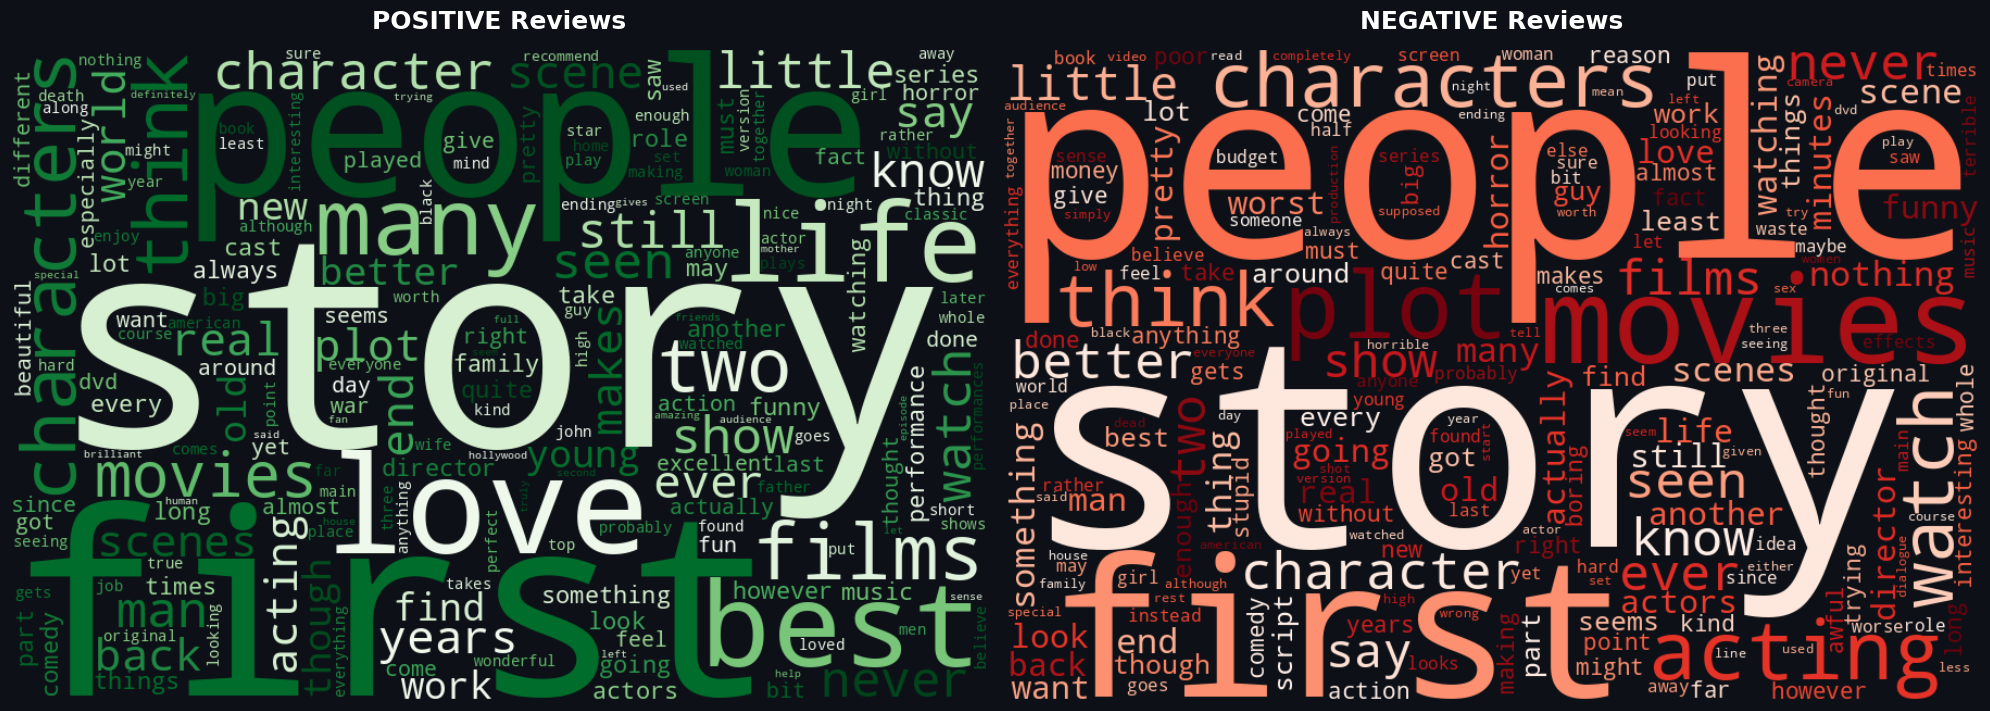

Đã lưu: /content/b_wordcloud.png


In [11]:
# ---- Word Cloud ----
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

for ax, tokens, freq, title, bg, cmap in [
    (axes[0], pos_tokens, pos_freq, 'POSITIVE Reviews', '#0d1117', 'Greens'),
    (axes[1], neg_tokens, neg_freq, 'NEGATIVE Reviews', '#0d1117', 'Reds')
]:
    wc = WordCloud(
        width=900, height=600,
        background_color=bg,
        colormap=cmap,
        max_words=200,
        collocations=False
    ).generate_from_frequencies(freq)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=18, fontweight='bold',
                 color='white' if bg == '#0d1117' else 'black', pad=15)
    ax.axis('off')

fig.patch.set_facecolor('#0d1117')
plt.tight_layout()
plt.savefig('/content/b_wordcloud.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Đã lưu: /content/b_wordcloud.png')

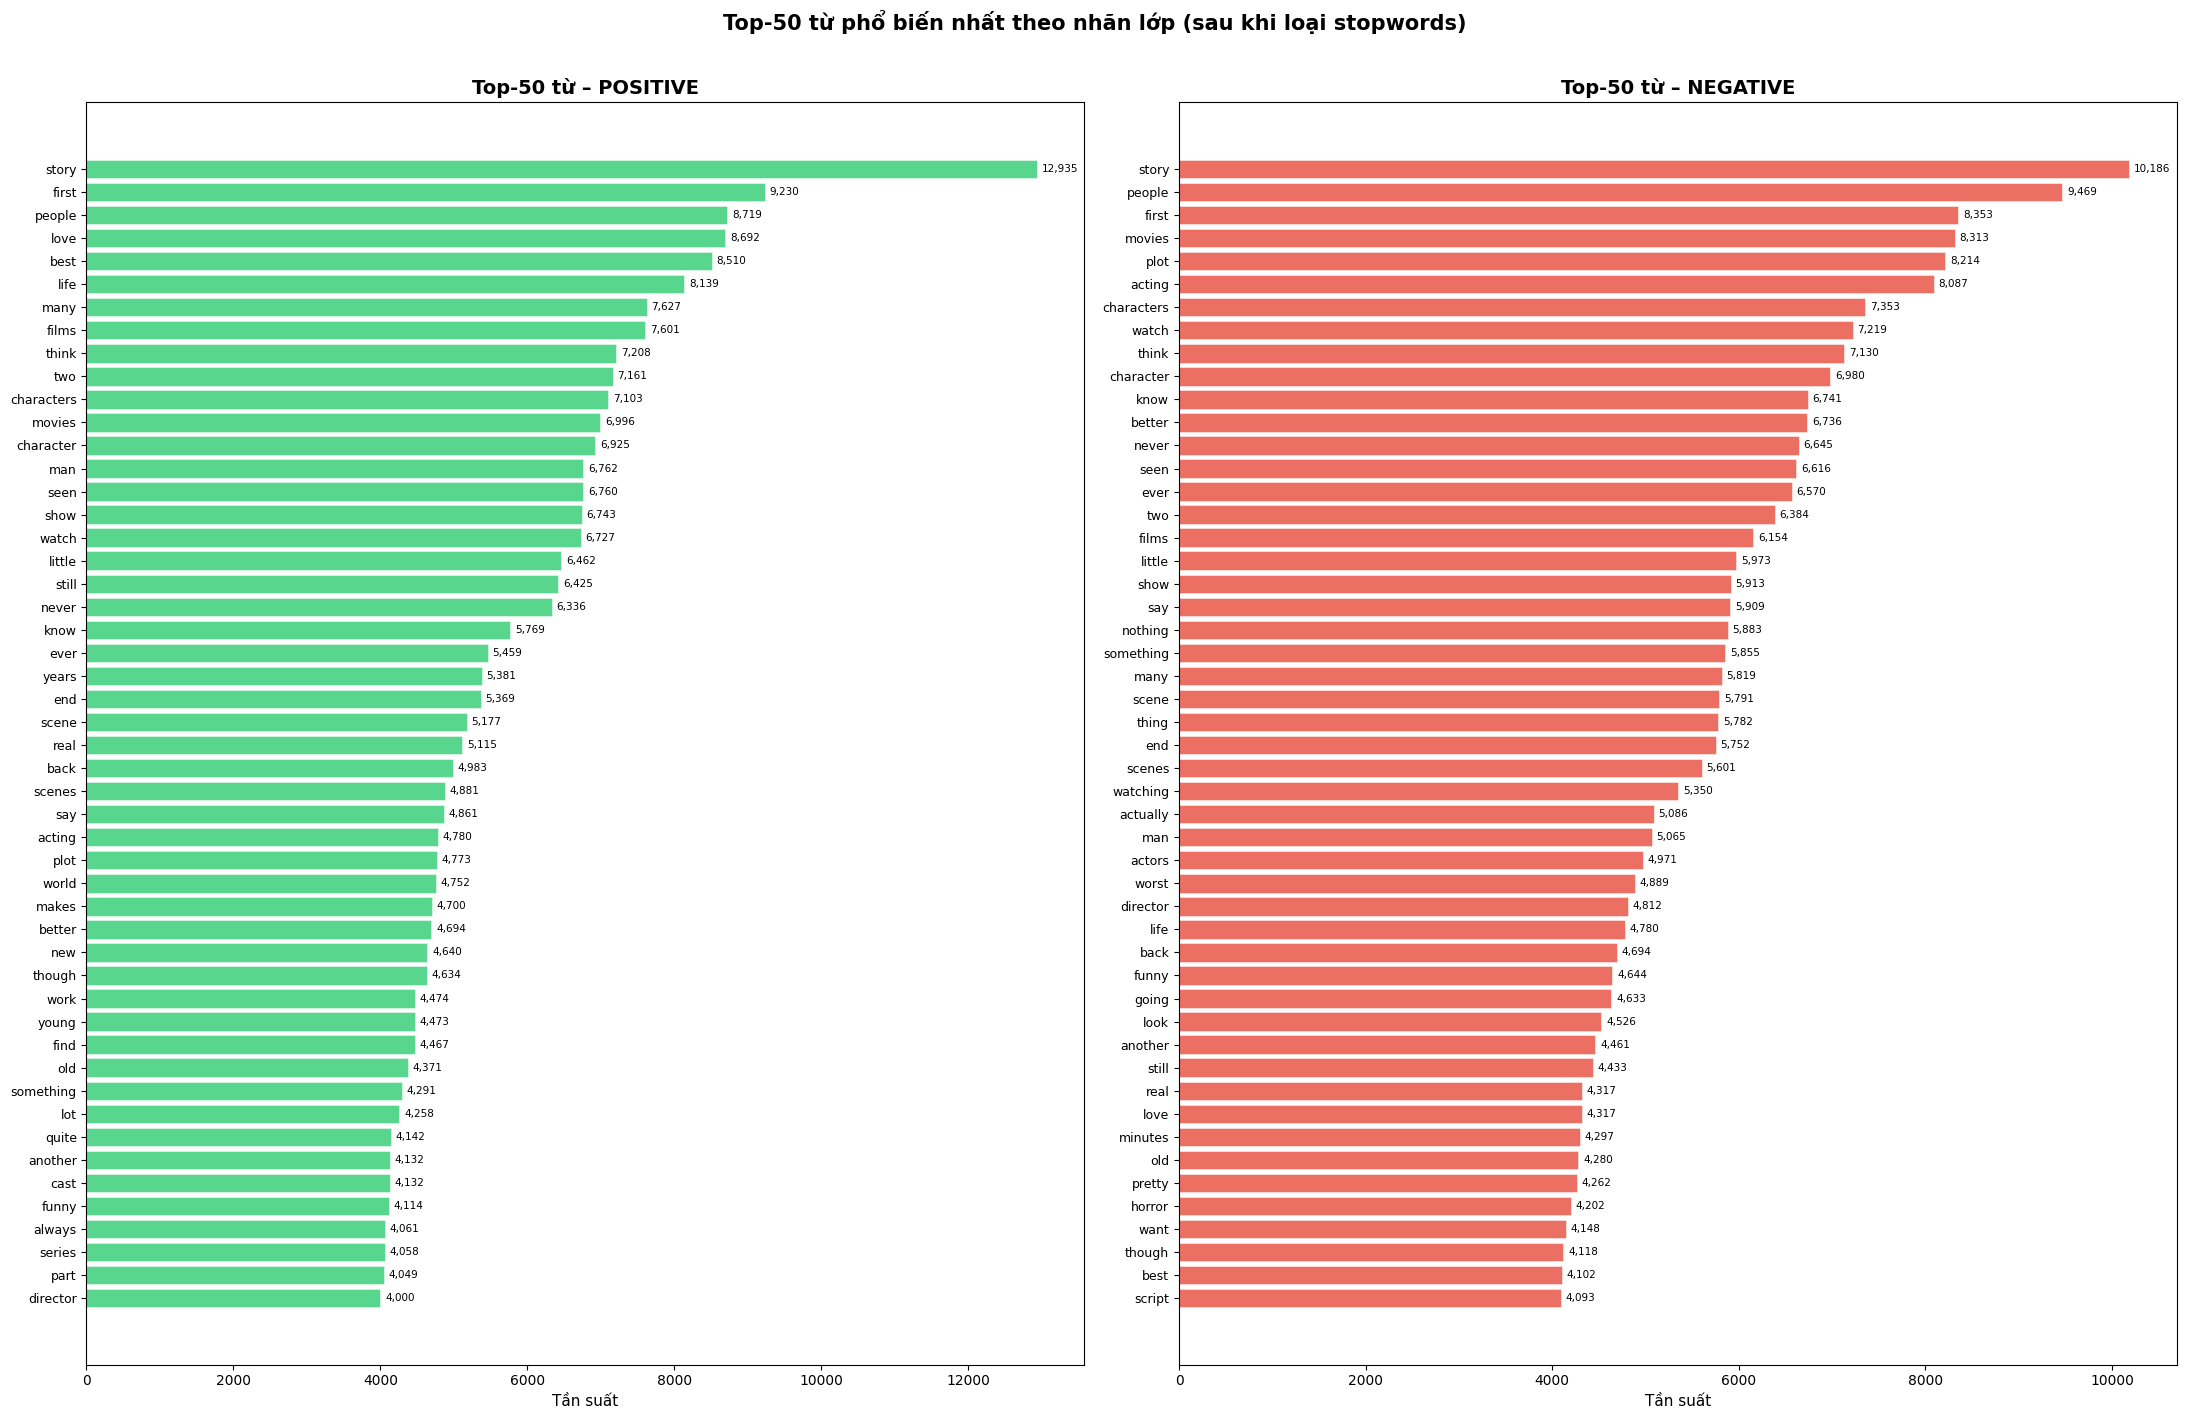

Đã lưu: /content/b_top50_words.png


In [12]:
# ---- Bảng Top-50 và Bar Chart ----
fig, axes = plt.subplots(1, 2, figsize=(22, 14))

for ax, df_top, title, color in [
    (axes[0], top50_pos, 'Top-50 từ – POSITIVE', '#2ecc71'),
    (axes[1], top50_neg, 'Top-50 từ – NEGATIVE', '#e74c3c')
]:
    col_name = df_top.columns[1]
    bars = ax.barh(range(len(df_top)), df_top[col_name], color=color, alpha=0.8, edgecolor='white', lw=0.4)
    ax.set_yticks(range(len(df_top)))
    ax.set_yticklabels(df_top['Word'], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Tần suất', fontsize=11)
    ax.set_title(title, fontsize=14, fontweight='bold')
    # Thêm giá trị lên mỗi bar
    for i, v in enumerate(df_top[col_name]):
        ax.text(v + max(df_top[col_name])*0.005, i, f'{v:,}', va='center', fontsize=7.5)

plt.suptitle('Top-50 từ phổ biến nhất theo nhãn lớp (sau khi loại stopwords)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/b_top50_words.png', dpi=150, bbox_inches='tight')
plt.show()
print('Đã lưu: /content/b_top50_words.png')

,Sentiment,Total Tokens (N),Unique Types (V),TTR (V/N)
0,Positive,2678786,73615,0.027481
1,Negative,2562626,70634,0.027563


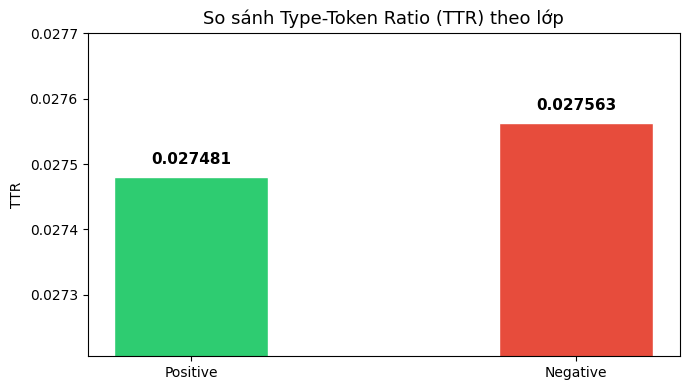

In [13]:
# ---- Hiển thị bảng TTR ----
ttr_table = pd.DataFrame({
    'Sentiment': ['Positive', 'Negative'],
    'Total Tokens (N)': [len(pos_tokens), len(neg_tokens)],
    'Unique Types (V)': [len(set(pos_tokens)), len(set(neg_tokens))],
    'TTR (V/N)': [round(ttr_pos, 6), round(ttr_neg, 6)]
})
display(ttr_table)

# Vẽ so sánh TTR
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['Positive', 'Negative'], [ttr_pos, ttr_neg],
              color=['#2ecc71', '#e74c3c'], width=0.4, edgecolor='white')
ax.set_ylim(min(ttr_pos, ttr_neg) * 0.99, max(ttr_pos, ttr_neg) * 1.005)
ax.set_ylabel('TTR')
ax.set_title('So sánh Type-Token Ratio (TTR) theo lớp', fontsize=13)
for bar, val in zip(bars, [ttr_pos, ttr_neg]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.00002,
            f'{val:.6f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/b_ttr.png', dpi=150, bbox_inches='tight')
plt.show()

### Phân tích kết quả – Phần b)

#### 1. Word Cloud trực quan hóa từ vựng theo nhãn
Nhìn vào Word Cloud của hai lớp, có thể nhận thấy ngay một số điểm nổi bật:

**Positive Reviews (nền đen – xanh lá):**
- Các từ **kích thước lớn nhất**: *story, people, first, many, best, love, life, character, films, acting, movies*
- Từ mang cảm xúc tích cực hiện diện rõ: **best, love, beautiful, always, performance**
- Từ mô tả tổng thể tác phẩm tích cực: **cast, director, series, comedy, family**
- Không gian màu sắc xanh lá tươi → trực quan gợi cảm giác tích cực, dễ chịu

**Negative Reviews (nền đen – đỏ cam):**
- Các từ **kích thước lớn nhất**: *story, first, people, plot, characters, acting, watch, movies*
- Từ mang cảm xúc tiêu cực nổi bật: **worst, terrible, waste, never, nothing, bad, boring**
- Từ phê phán kỹ thuật: **plot, script, acting, director, budget** → người xem tiêu cực tập trung chỉ trích các yếu tố kỹ thuật làm phim
- Từ **minutes** xuất hiện đáng chú ý → gợi ý cụm "waste of time / X minutes wasted"

**So sánh trực quan hai Word Cloud:**
- **Từ chung (domain IMDB):** *story, people, first, characters, acting, films, movies, watch, show, scene* — xuất hiện ở cả hai với kích thước lớn, phản ánh chủ đề chung là bình luận phim.
- **Điểm khác biệt rõ nhất:** Positive có *best, love, beautiful, comedy, family* nổi bật; Negative có *worst, terrible, plot, nothing, waste* nổi bật → các **tính từ và danh từ đánh giá** là tín hiệu sentiment mạnh nhất, phù hợp để dùng làm đặc trưng cho bài toán classification.

---

#### 2. Top-50 từ phổ biến theo nhãn lớp

| Hạng | Positive (count) | Negative (count) |
|------|-----------------|-----------------|
| 1 | story (12,935) | story (10,186) |
| 2 | first (9,230) | people (9,469) |
| 3 | people (8,719) | first (8,353) |
| 4 | love (8,692) | movies (8,313) |
| 5 | best (8,510) | plot (8,214) |
| 6 | life (8,139) | acting (8,087) |
| 7 | many (7,627) | characters (7,353) |
| 8 | films (7,601) | watch (7,219) |
| 9 | think (7,208) | think (7,130) |
| 10 | two (7,161) | character (6,980) |

**Từ chung (xuất hiện trong top-50 của cả hai lớp):** *story, people, first, films/movies, characters/character, think, two, seen, show, watch, little, still, never, know, ever, scene, scenes, say, many, end, man, back, better, life, real, something, though*

→ Đây là các từ **domain-specific** của IMDB, mô tả nội dung phim mà không mang nghĩa sentiment rõ ràng.

**Từ đặc trưng Positive (xuất hiện nổi bật hơn ở positive):** *love, best, life, young, work, world, makes, cast, series, always, quite, funny, find*

→ Nghiêng về cảm xúc **tích cực và mô tả giá trị**: *love, best* là hai từ định lượng cảm xúc tốt nhất; *cast, series, world* phản ánh xu hướng khen ngợi tổng thể tác phẩm.

**Từ đặc trưng Negative (xuất hiện nổi bật hơn ở negative):** *plot, acting, characters, watch, nothing, worst, director, minutes, horror, script, want, actually, actors*

→ Nghiêng về **phê phán kỹ thuật làm phim**: *worst, nothing, script, minutes* cho thấy người xem tiêu cực tập trung chỉ trích cốt truyện, diễn xuất và cảm giác lãng phí thời gian. Đặc biệt, từ *minutes* trong top Negative gợi ý người viết hay đề cập "X minutes of my life wasted".

---

#### 3. Type-Token Ratio (TTR)

| Sentiment | Total Tokens (N) | Unique Types (V) | TTR |
|-----------|-----------------|-----------------|-----|
| Positive | 2,678,786 | 73,615 | **0.027481** |
| Negative | 2,562,626 | 70,634 | **0.027563** |
| Chênh lệch | +116,160 tokens | +2,981 types | **+0.000082** (Negative cao hơn) |

**Nhận xét:**

- **TTR của cả hai lớp rất nhỏ (~0.0275)** — hoàn toàn bình thường với corpus ~2.5 triệu token. Khi N tăng, các từ phổ biến lặp lại rất nhiều lần khiến TTR giảm theo quy luật Zipf.

- **Negative có TTR cao hơn một chút (0.027563 > 0.027481, chênh 0.000082):** Điều này cho thấy lớp Negative sử dụng từ vựng **đa dạng hơn nhẹ** so với Positive. Có thể lý giải: người viết review tiêu cực thường dùng nhiều cách diễn đạt khác nhau để phàn nàn (về cốt truyện, diễn xuất, đạo diễn, kịch bản...), trong khi review tích cực có xu hướng lặp lại các từ khen ngợi quen thuộc như *love, best, great, amazing*.

- **Lưu ý quan trọng về tính công bằng của so sánh:** Corpus Positive có N lớn hơn (~116,000 tokens), về lý thuyết điều này sẽ khiến TTR của Positive *nhỏ hơn* một chút so với Negative dù vocabulary thực sự tương đương. Chênh lệch TTR rất nhỏ (0.000082) nên **không thể kết luận mạnh** rằng một lớp phong phú từ vựng hơn hẳn — hai lớp thực chất có độ phong phú từ vựng **gần tương đương nhau**.

- **Kết luận thực tiễn:** TTR không phải đặc trưng phân biệt sentiment tốt. Để đánh giá lexical richness chính xác hơn khi corpus có kích thước khác nhau, có thể dùng **MATTR** (Moving Average TTR) hoặc **MTLD** trong các phân tích nâng cao.

---
<a id='partC'></a>
## c) Phân tích phân phối Zipf

### Lý thuyết

#### Định luật Zipf
Định luật Zipf (George Kingsley Zipf, 1949) là một quy luật thực nghiệm quan sát thấy trong hầu hết các ngôn ngữ tự nhiên:

> **Tần suất của một từ tỉ lệ nghịch với thứ hạng của nó trong bảng tần suất.**

Công thức chính thức:
$$f(r) = \frac{C}{r^{\alpha}}$$

Trong đó:
- $f(r)$ = tần suất của từ có hạng $r$
- $r$ = hạng (rank) của từ (từ phổ biến nhất có $r = 1$)
- $\alpha$ = hệ số Zipf (lý tưởng $\alpha \approx 1$)
- $C$ = hằng số chuẩn hóa

#### Log-log linearization
Lấy logarithm hai vế:
$$\log f(r) = \log C - \alpha \log r$$

Trên không gian log-log, định luật Zipf thể hiện như một **đường thẳng** với **độ dốc (slope) = $-\alpha$**.

- **Zipf lý tưởng:** $\alpha = 1$ → slope = $-1$
- **Thực tế:** $\alpha$ thường nằm trong khoảng $[0.8, 1.2]$ và đường thẳng chỉ fit tốt ở vùng giữa (bỏ qua đầu và đuôi phân phối)

#### Ý nghĩa trong NLP
- **Phần đầu (head):** Một số ít từ rất phổ biến (high-frequency words) → thường là function words (stopwords)
- **Phần đuôi (tail) – Long tail:** Rất nhiều từ hiếm gặp → hapax legomena (từ chỉ xuất hiện một lần)
- Đặc tính này giải thích tại sao NLP cần xử lý **vocabulary sparsity** và tại sao các kỹ thuật như **TF-IDF, subword tokenization (BPE)** quan trọng

In [14]:
from scipy.stats import linregress

def compute_zipf_data(tokens):
    """Tính rank-frequency data từ list tokens."""
    freq = Counter(tokens)
    # Sắp xếp theo tần suất giảm dần
    sorted_freq = sorted(freq.values(), reverse=True)
    ranks = np.arange(1, len(sorted_freq) + 1)
    frequencies = np.array(sorted_freq)
    return ranks, frequencies

# Tính cho toàn bộ corpus và theo từng lớp
all_tokens = pos_tokens + neg_tokens
ranks_all, freqs_all = compute_zipf_data(all_tokens)
ranks_pos, freqs_pos = compute_zipf_data(pos_tokens)
ranks_neg, freqs_neg = compute_zipf_data(neg_tokens)

print(f'Tổng từ duy nhất (all corpus): {len(ranks_all):,}')
print(f'Top-5 từ phổ biến nhất (all): {Counter(all_tokens).most_common(5)}')

Tổng từ duy nhất (all corpus): 98,739
Top-5 từ phổ biến nhất (all): [('story', 23121), ('people', 18188), ('first', 17583), ('movies', 15309), ('characters', 14456)]


In [15]:
def fit_zipf(ranks, freqs, low_pct=0.05, high_pct=0.70):
    """
    Fit đường thẳng trên log-log space.
    Chỉ dùng phần giữa (bỏ head và tail) để fit chính xác hơn.
    """
    n = len(ranks)
    low = int(n * low_pct)
    high = int(n * high_pct)
    log_r = np.log10(ranks[low:high])
    log_f = np.log10(freqs[low:high])
    slope, intercept, r_value, p_value, std_err = linregress(log_r, log_f)
    return slope, intercept, r_value**2

slope_all, intercept_all, r2_all = fit_zipf(ranks_all, freqs_all)
slope_pos, intercept_pos, r2_pos = fit_zipf(ranks_pos, freqs_pos)
slope_neg, intercept_neg, r2_neg = fit_zipf(ranks_neg, freqs_neg)

print('=== Kết quả hồi quy tuyến tính trên log-log space ===')
print(f'All corpus  → slope (α) = {slope_all:.4f}, intercept = {intercept_all:.4f}, R² = {r2_all:.4f}')
print(f'Positive    → slope (α) = {slope_pos:.4f}, intercept = {intercept_pos:.4f}, R² = {r2_pos:.4f}')
print(f'Negative    → slope (α) = {slope_neg:.4f}, intercept = {intercept_neg:.4f}, R² = {r2_neg:.4f}')
print(f'\nĐịnh luật Zipf lý tưởng: α = -1.0')
print(f'Độ lệch khỏi Zipf lý tưởng (|α - (-1)|):')
for name, s in [('All', slope_all), ('Positive', slope_pos), ('Negative', slope_neg)]:
    print(f'  {name}: {abs(s - (-1)):.4f}')

=== Kết quả hồi quy tuyến tính trên log-log space ===
All corpus  → slope (α) = -2.0069, intercept = 9.8188, R² = 0.9796
Positive    → slope (α) = -1.8683, intercept = 8.9368, R² = 0.9766
Negative    → slope (α) = -1.8396, intercept = 8.7621, R² = 0.9776

Định luật Zipf lý tưởng: α = -1.0
Độ lệch khỏi Zipf lý tưởng (|α - (-1)|):
  All: 1.0069
  Positive: 0.8683
  Negative: 0.8396


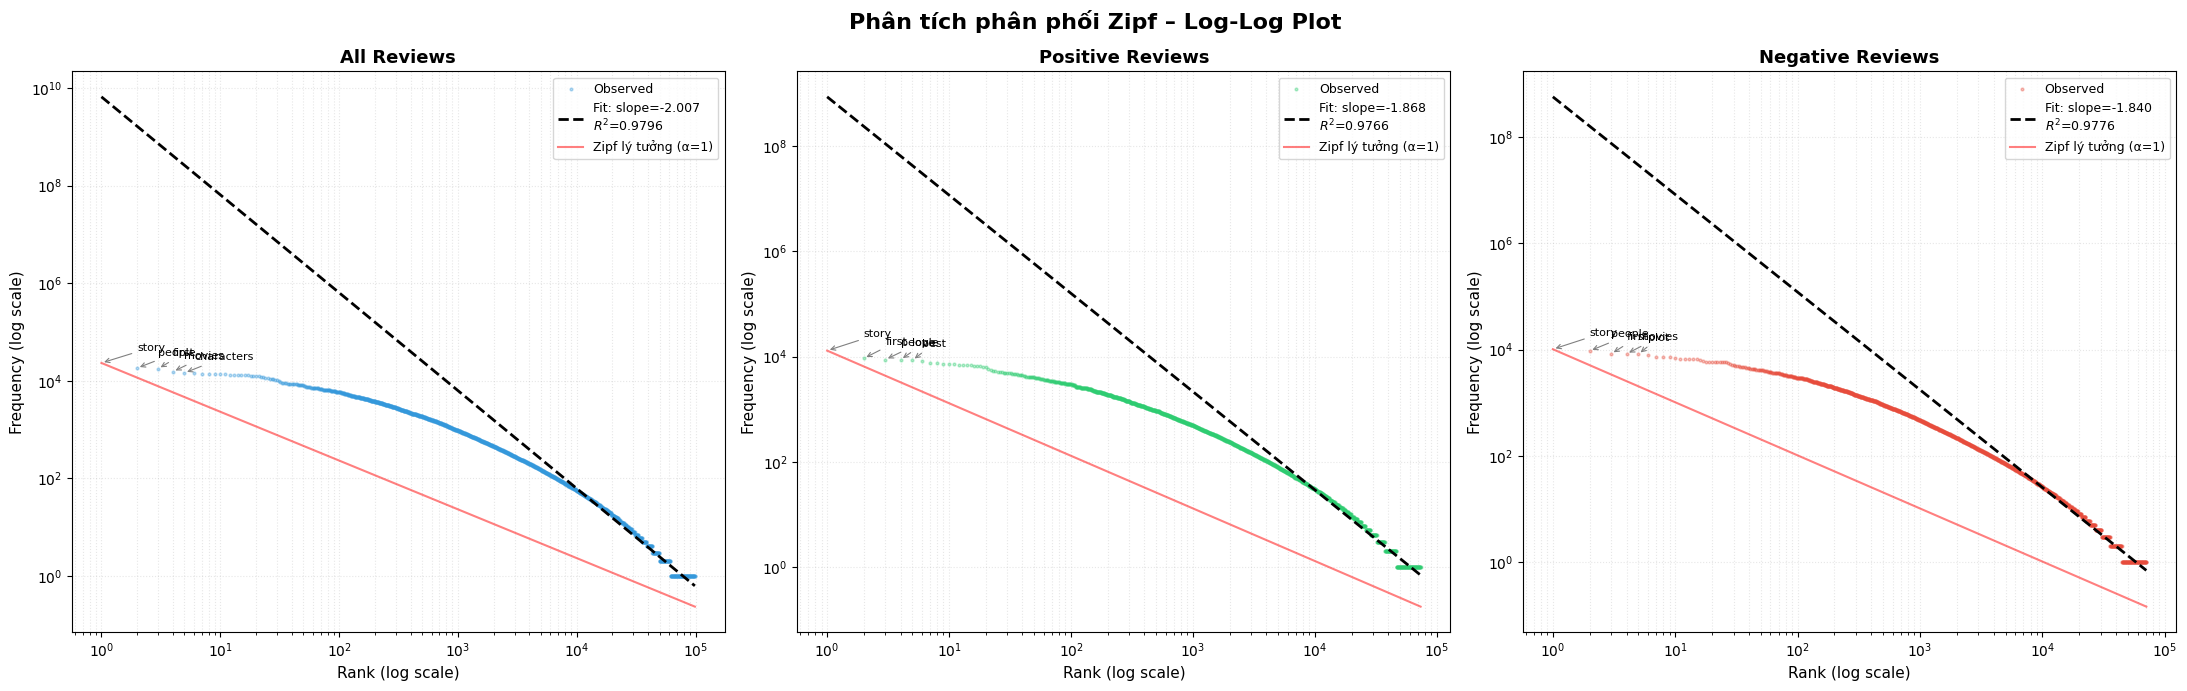

Đã lưu: /content/c_zipf_analysis.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle("Phân tích phân phối Zipf – Log-Log Plot", fontsize=16, fontweight='bold')

datasets = [
    (ranks_all, freqs_all, slope_all, intercept_all, r2_all, '#3498db', 'All Reviews'),
    (ranks_pos, freqs_pos, slope_pos, intercept_pos, r2_pos, '#2ecc71', 'Positive Reviews'),
    (ranks_neg, freqs_neg, slope_neg, intercept_neg, r2_neg, '#e74c3c', 'Negative Reviews'),
]

for ax, (ranks, freqs, slope, intercept, r2, color, title) in zip(axes, datasets):
    # Scatter plot (dùng sample để vẽ nhanh)
    sample_idx = np.unique(np.round(np.logspace(0, np.log10(len(ranks)-1), 2000)).astype(int))
    sample_idx = sample_idx[sample_idx < len(ranks)]
    ax.scatter(ranks[sample_idx], freqs[sample_idx],
               s=4, alpha=0.35, color=color, label='Observed', zorder=2)

    # Đường fit
    r_fit = np.logspace(0, np.log10(len(ranks)), 300)
    f_fit = 10**intercept * r_fit**slope
    ax.plot(r_fit, f_fit, 'k--', lw=2, label=f'Fit: slope={slope:.3f}\n$R^2$={r2:.4f}', zorder=3)

    # Đường Zipf lý tưởng (α=1)
    f_ideal = freqs[0] * (1.0 / r_fit)  # C = f(1)
    ax.plot(r_fit, f_ideal, 'r-', lw=1.5, alpha=0.5, label='Zipf lý tưởng (α=1)', zorder=3)

    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Rank (log scale)', fontsize=11)
    ax.set_ylabel('Frequency (log scale)', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, which='both', alpha=0.3, ls=':')

    # Annotation top-5 từ
    all_freq_sorted = sorted(Counter(all_tokens if title == 'All Reviews'
                                     else (pos_tokens if 'Positive' in title else neg_tokens)
                                     ).items(), key=lambda x: -x[1])
    for i, (word, freq) in enumerate(all_freq_sorted[:5]):
        ax.annotate(word, xy=(i+1, freqs[i]),
                    xytext=(i+2, freqs[i]*1.8),
                    fontsize=8, color='black',
                    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

plt.tight_layout()
plt.savefig('/content/c_zipf_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Đã lưu: /content/c_zipf_analysis.png')

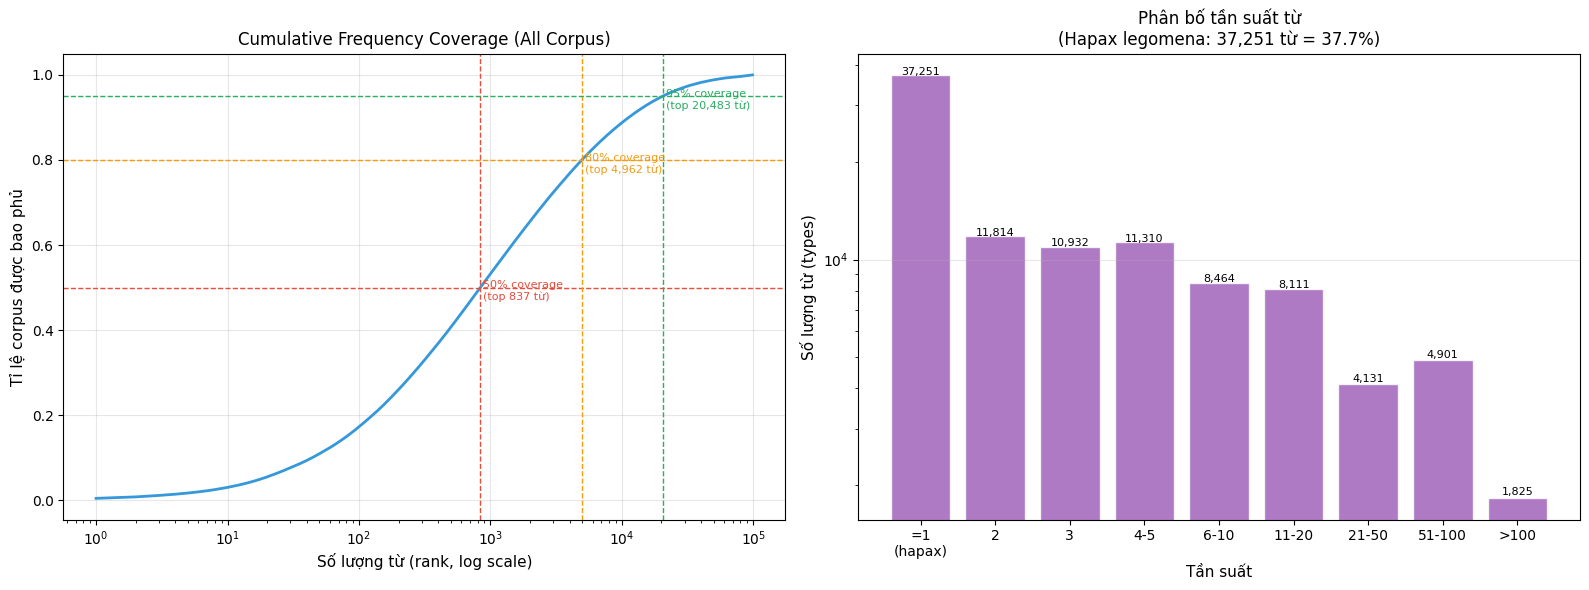

Đã lưu: /content/c_zipf_analysis2.png

Hapax legomena (từ chỉ xuất hiện 1 lần): 37,251 / 98,739 từ (37.7%)


In [17]:
# ---- Phân tích thêm: Hapax Legomena và Cumulative Frequency ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Cumulative coverage
ax = axes[0]
cum_freq = np.cumsum(freqs_all) / freqs_all.sum()
ax.plot(ranks_all, cum_freq, color='#3498db', lw=2)
# Đánh dấu 50%, 80%, 95%
for pct, c in [(0.5, '#e74c3c'), (0.8, '#f39c12'), (0.95, '#27ae60')]:
    idx = np.searchsorted(cum_freq, pct)
    ax.axhline(pct, color=c, ls='--', lw=1)
    ax.axvline(idx, color=c, ls='--', lw=1)
    ax.text(idx * 1.05, pct - 0.03, f'{pct*100:.0f}% coverage\n(top {idx:,} từ)',
            fontsize=8, color=c)
ax.set_xscale('log')
ax.set_xlabel('Số lượng từ (rank, log scale)', fontsize=11)
ax.set_ylabel('Tỉ lệ corpus được bao phủ', fontsize=11)
ax.set_title('Cumulative Frequency Coverage (All Corpus)', fontsize=12)
ax.grid(True, alpha=0.3)

# 2. Frequency distribution (histogram of frequencies)
ax2 = axes[1]
hapax_all = sum(1 for f in freqs_all if f == 1)
hapax_pct = hapax_all / len(freqs_all) * 100
bins = [1, 2, 3, 5, 10, 20, 50, 100, 500, np.inf]
labels = ['=1\n(hapax)', '2', '3', '4-5', '6-10', '11-20', '21-50', '51-100', '>100']
counts = []
for i in range(len(bins)-1):
    count = sum(1 for f in freqs_all if bins[i] <= f < bins[i+1])
    counts.append(count)
bars = ax2.bar(labels, counts, color='#9b59b6', alpha=0.8, edgecolor='white')
ax2.set_xlabel('Tần suất', fontsize=11)
ax2.set_ylabel('Số lượng từ (types)', fontsize=11)
ax2.set_title(f'Phân bố tần suất từ\n(Hapax legomena: {hapax_all:,} từ = {hapax_pct:.1f}%)', fontsize=12)
for bar, cnt in zip(bars, counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{cnt:,}', ha='center', fontsize=8)
ax2.set_yscale('log')
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/c_zipf_analysis2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Đã lưu: /content/c_zipf_analysis2.png')
print(f'\nHapax legomena (từ chỉ xuất hiện 1 lần): {hapax_all:,} / {len(freqs_all):,} từ ({hapax_pct:.1f}%)')

In [18]:
# ---- Bảng tổng kết Zipf ----
zipf_summary = pd.DataFrame({
    'Corpus': ['All Reviews', 'Positive', 'Negative'],
    'Vocab Size (V)': [len(ranks_all), len(ranks_pos), len(ranks_neg)],
    'Total Tokens (N)': [len(all_tokens), len(pos_tokens), len(neg_tokens)],
    'Zipf α (slope)': [round(-slope_all, 4), round(-slope_pos, 4), round(-slope_neg, 4)],
    'R² (fit quality)': [round(r2_all, 4), round(r2_pos, 4), round(r2_neg, 4)],
    'Deviation from α=1': [round(abs(-slope_all - 1), 4),
                            round(abs(-slope_pos - 1), 4),
                            round(abs(-slope_neg - 1), 4)],
})
display(zipf_summary)

,Corpus,Vocab Size (V),Total Tokens (N),Zipf α (slope),R² (fit quality),Deviation from α=1
0,All Reviews,98739,5241412,2.0069,0.9796,1.0069
1,Positive,73615,2678786,1.8683,0.9766,0.8683
2,Negative,70634,2562626,1.8396,0.9776,0.8396


### Phân tích kết quả – Phần c)

#### 1. Bảng tổng kết hồi quy Zipf

| Corpus | Vocab Size (V) | Total Tokens (N) | α (slope) | R² | Deviation \|α−1\| |
|--------|---------------|-----------------|-----------|-----|-------------------|
| All Reviews | 98,739 | 5,241,412 | 2.0069 | 0.9796 | **1.0069** |
| Positive | 73,615 | 2,678,786 | 1.8683 | 0.9766 | **0.8683** |
| Negative | 70,634 | 2,562,626 | 1.8396 | 0.9776 | **0.8396** |

---

#### 2. Log-Log Plot – Nhận xét trực quan

Nhìn vào đồ thị log-log của cả 3 corpus, có thể thấy rõ 3 vùng đặc trưng:

- **Vùng head (rank nhỏ, ~1–100):** Đường thực tế (màu xanh/đỏ) nằm **rất xa bên dưới** đường fit và đường Zipf lý tưởng. Top-5 từ phổ biến nhất (*story* 23,121; *people* 18,188; *first* 17,583; *movies* 15,309; *characters* 14,456) có tần suất cao nhưng **không cao bằng dự đoán của Zipf lý tưởng** — điều này phổ biến trong corpus sau khi đã loại stopwords, vì các function words tần suất cực cao đã bị loại bỏ.

- **Vùng giữa (rank ~100–10,000):** Đường quan sát và đường fit **gần như trùng khớp**, R² đạt 0.976–0.980 → đây là vùng tuân theo Zipf tốt nhất, xác nhận corpus IMDB có cấu trúc từ vựng đặc trưng của ngôn ngữ tự nhiên.

- **Vùng tail (rank > 10,000):** Đường quan sát **nằm trên** đường fit rồi đột ngột rơi xuống → phần đuôi chứa rất nhiều từ hiếm (hapax legomena và near-hapax), sau đó frequency về 1 và kết thúc.

---

#### 3. Phân tích hệ số α và mức độ tuân theo định luật Zipf

**Kết quả đáng chú ý: α >> 1 (không phải ≈ 1)**

| Corpus | α thực tế | Deviation \|α−1\| | Đánh giá |
|--------|-----------|-------------------|----------|
| All Reviews | **2.007** | 1.007 | Dốc gấp đôi Zipf lý tưởng |
| Positive | **1.868** | 0.868 | Dốc hơn Zipf lý tưởng đáng kể |
| Negative | **1.840** | 0.840 | Dốc hơn Zipf lý tưởng đáng kể |

α > 1 có nghĩa là tần suất **giảm nhanh hơn** so với Zipf lý tưởng khi rank tăng. Nguyên nhân chính:
- **Stopwords đã bị loại bỏ:** Định luật Zipf lý tưởng (α ≈ 1) thường được quan sát trên raw text bao gồm cả function words (*the, a, is, of*...) — những từ này tạo nên phần đầu tần suất cực cao, làm cho đường dốc nhẹ hơn. Sau khi loại stopwords, các từ nội dung (content words) có phân phối dốc hơn.
- **All corpus có α = 2.007 cao hơn từng lớp riêng lẻ:** Do gộp 2 corpus lại làm tăng tần suất lặp của các từ phổ biến ở head, khiến đuôi tương đối thưa hơn → slope lớn hơn.
- **Positive (α=1.868) và Negative (α=1.840) gần bằng nhau:** Hai lớp có cấu trúc phân phối từ vựng **tương đồng**, không có sự khác biệt đáng kể về dạng phân phối Zipf.

Mặc dù α lệch khỏi 1, R² đều đạt **≥ 0.976** → mối quan hệ rank-frequency **vẫn tuyến tính rõ ràng trên log-log space**, tức corpus IMDB **vẫn tuân theo dạng power-law** đặc trưng của Zipf, chỉ với hệ số dốc khác lý thuyết cổ điển.

---

#### 4. Cumulative Coverage & Hapax Legomena

**Cumulative Frequency Coverage:**

| Ngưỡng bao phủ | Số từ cần thiết | % so với tổng vocab (98,739) |
|---------------|----------------|------------------------------|
| 50% corpus | **837 từ** | 0.85% |
| 80% corpus | **4,962 từ** | 5.02% |
| 95% corpus | **20,483 từ** | 20.74% |

→ Chỉ cần **837 từ** (< 1% vocabulary) đã đủ để bao phủ **nửa** toàn bộ corpus — minh chứng rõ nét cho hiệu ứng Zipf. Ngược lại, cần đến ~79% vocabulary còn lại để bao phủ 5% corpus cuối cùng.

**Phân bố tần suất từ & Hapax Legomena:**

| Nhóm tần suất | Số types | Ghi chú |
|--------------|---------|---------|
| = 1 (hapax) | **37,251** | **37.7%** tổng vocabulary |
| 2 | 11,814 | 12.0% |
| 3 | 10,932 | 11.1% |
| 4–5 | 11,310 | 11.5% |
| 6–10 | 8,464 | 8.6% |
| 11–20 | 8,111 | 8.2% |
| 21–50 | 4,131 | 4.2% |
| 51–100 | 4,901 | 5.0% |
| > 100 | 1,825 | 1.8% |

- **37,251 hapax legomena = 37.7%** tổng vocabulary: gần **2 trong 5 từ duy nhất** chỉ xuất hiện đúng 1 lần trong toàn bộ 50K reviews — thể hiện độ thưa thớt (sparsity) rất cao của không gian từ vựng.
- Các từ xuất hiện ≤ 5 lần chiếm đến **70.3%** vocabulary nhưng đóng góp rất ít vào tổng token count.

---

#### 5. Ý nghĩa thực tiễn với Data Mining / NLP

1. **Vocabulary truncation:** Kết quả cumulative coverage cho thấy chỉ cần giữ top ~5,000–20,000 từ là đủ bao phủ 80–95% corpus → nên cắt vocabulary ở ngưỡng này khi xây dựng feature vector để giảm chiều và loại nhiễu từ hapax.
2. **TF-IDF phù hợp:** Phân phối Zipf xác nhận một số ít từ rất phổ biến và rất nhiều từ hiếm → TF-IDF hoạt động hiệu quả vì downweight từ phổ biến (head) và highlight từ discriminative ở vùng giữa.
3. **Subword tokenization (BPE/WordPiece):** 37.7% hapax legomena là lý do chính khiến các mô hình hiện đại dùng subword để xử lý OOV.
4. **Corpus IMDB là corpus ngôn ngữ tự nhiên hợp lệ:** R² > 0.976 và dạng power-law rõ ràng xác nhận không có dấu hiệu bất thường về phân phối từ, dữ liệu đáng tin cậy cho các tác vụ NLP.